# Routing Control Ablation Results

**Source**: `ablation_dualset_core_global_queue_v1` (beauty + KuaiRecLargeStrictPosV2_0.2)  
**Protocol**: per-seed best-valid trial → `test_mrr20`; average across seeds (S1–S4)  
**Baseline**: `base_test_mrr20` from the selected base model JSON (full FMoE run)  
**Filter**: `trigger == 'run_complete'` AND `status == 'run_complete'`

Figures are split by **dataset** and by **figure type** (absolute MRR / relative lift).

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Paths ──────────────────────────────────────────────────────────────────
V1_ROOT = Path(
    "/workspace/FeaturedMoE/experiments/run/artifacts/logs/fmoe_n4/ablation"
    "/ablation_dualset_core_global_queue_v1"
)

DATASET_KEYS = [
    "beauty",
    "KuaiRecLargeStrictPosV2_0.2",
]
DATASET_LABELS = {
    "beauty": "Beauty",
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRec",
}

# ── Routing-control variant order and labels ────────────────────────────────
# RC-01 … RC-13 from setting_id column
RC_ORDER = [f"RC-{i:02d}" for i in range(1, 14)]

RC_LABELS = {
    "RC-01": "SHARED_FFN\n(Dense, no routing)",
    "RC-02": "ROUTER_SRC_HIDDEN\n(Hidden-only)",
    "RC-03": "ROUTER_SRC_BOTH\n(Hidden+Feat ★)",
    "RC-04": "ROUTER_SRC_FEATURE\n(Feature-only)",
    "RC-05": "NO_ROUTER_BIAS_INJ\n(Dense+gated bias)",
    "RC-06": "NO_ROUTER_GRP_BIAS\n(Dense+group bias)",
    "RC-07": "GLOBAL_TOPK_4/12\n(Global budget)",
    "RC-08": "PER_GRP_TOPK_1\n(Per-group top-1)",
    "RC-09": "GROUP_TOPK_2\n(Group top-2)",
    "RC-10": "GRP_TOPK_2×1\n(2grp × inner-1)",
    "RC-11": "ALL_SESSION\n(Session routing)",
    "RC-12": "ALL_TOKEN\n(Token routing)",
    "RC-13": "INJ_GATED_BIAS\n(Routing+bias inj)",
}

# Tier: essential (RC-01..06) vs extended (RC-07..13)
RC_TIER = {rc: ("essential" if int(rc.split("-")[1]) <= 6 else "extended") for rc in RC_ORDER}

# ── Color palette ──────────────────────────────────────────────────────────
CLR_ESSENTIAL = "#4C72B0"   # blue
CLR_EXTENDED  = "#DD8452"   # orange
CLR_BASELINE  = "#2ca02c"   # green
CLR_FULL_RC   = "#9467bd"   # purple (RC-03: full-model routing in ablation)

print("Setup complete.")

Setup complete.


In [19]:

import json
from glob import glob

RESULTS_ROOT = Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4")

# BL-00 JSON glob patterns (4-seed runs, same runtime as ablation)
BL00_GLOBS = {
    "beauty":                    "beauty_FeaturedMoE_N3_p40_beauty_b01_b25_lr_h8_seen_anchor_bl_00_s*_20260416_165814_*.json",
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p40_kuaireclargestrictposv2_0_2_b01_s02_h14_seen_hi_bl_00_s*_20260416_164625_*.json",
}


def _best_trial_test_metrics(json_path: str) -> dict:
    with open(json_path) as f:
        js = json.load(f)
    best = max(js["trials"], key=lambda t: t.get("mrr@20", 0))
    return best.get("test_result", {})


def load_bl00(dataset_key: str) -> dict:
    """Load BL-00 baseline metrics averaged across seeds."""
    paths = sorted(glob(str(RESULTS_ROOT / BL00_GLOBS[dataset_key])))
    assert paths, f"No BL-00 JSONs found for {dataset_key}"
    rows = [_best_trial_test_metrics(p) for p in paths]
    hr10s   = [r.get("hit@10",  float("nan")) for r in rows]
    ndcg20s = [r.get("ndcg@20", float("nan")) for r in rows]
    mrr20s  = [r.get("mrr@20",  float("nan")) for r in rows]
    return {
        "mean_mrr20":  float(np.nanmean(mrr20s)),
        "std_mrr20":   float(np.nanstd(mrr20s)),
        "mean_hr10":   float(np.nanmean(hr10s)),
        "std_hr10":    float(np.nanstd(hr10s)),
        "mean_ndcg20": float(np.nanmean(ndcg20s)),
        "std_ndcg20":  float(np.nanstd(ndcg20s)),
        "n_seeds":     len(paths),
    }


def load_rc_data(dataset_key: str) -> pd.DataFrame:
    """Load routing-control ablation for one dataset → agg DataFrame."""
    csv_path = V1_ROOT / dataset_key / "summary.csv"
    df = pd.read_csv(csv_path)
    mask = (
        (df["trigger"] == "run_complete") &
        (df["status"]  == "run_complete") &
        (df["tuning_stage"] == "routing_control")
    )
    df = df[mask].copy()
    df = df.sort_values("timestamp_utc").drop_duplicates(
        subset=["setting_id", "seed_id"], keep="last"
    )
    records = []
    for _, row in df.iterrows():
        try:
            m = _best_trial_test_metrics(row["result_path"])
        except Exception as e:
            print(f"  WARN {row.get('result_path')}: {e}")
            m = {}
        records.append({
            "setting_id":  row["setting_id"],
            "seed_id":     row["seed_id"],
            "test_mrr20":  m.get("mrr@20",  row["test_mrr20"]),
            "test_hr10":   m.get("hit@10",  float("nan")),
            "test_ndcg20": m.get("ndcg@20", float("nan")),
            "setting_key": row["setting_key"],
        })
    rdf = pd.DataFrame(records)
    agg = (
        rdf.groupby("setting_id")
        .agg(
            mean_mrr20= ("test_mrr20",  "mean"), std_mrr20=  ("test_mrr20",  "std"),
            mean_hr10=  ("test_hr10",   "mean"), std_hr10=   ("test_hr10",   "std"),
            mean_ndcg20=("test_ndcg20", "mean"), std_ndcg20= ("test_ndcg20", "std"),
            n_seeds=    ("test_mrr20",  "count"),
            setting_key=("setting_key", "first"),
        )
        .reset_index()
    )
    agg = agg[agg["setting_id"].isin(RC_ORDER)].copy()
    agg["rc_num"] = agg["setting_id"].str.extract(r"RC-(\d+)").astype(int)
    agg = agg.sort_values("rc_num").drop(columns="rc_num").reset_index(drop=True)
    return agg


results  = {}
bl00     = {}
for ds in DATASET_KEYS:
    results[ds] = load_rc_data(ds)
    bl00[ds]    = load_bl00(ds)
    m = bl00[ds]
    print(f"{DATASET_LABELS[ds]} — BL-00 ({m['n_seeds']} seeds): "
          f"HR@10={m['mean_hr10']:.4f}±{m['std_hr10']:.4f}  "
          f"NDCG@20={m['mean_ndcg20']:.4f}±{m['std_ndcg20']:.4f}  "
          f"MRR@20={m['mean_mrr20']:.4f}±{m['std_mrr20']:.4f}")

print()
for ds in DATASET_KEYS:
    print(f"{DATASET_LABELS[ds]}:")
    print(results[ds][["setting_id","setting_key","n_seeds","mean_hr10","mean_ndcg20"]].to_string(index=False))
    print()


Beauty — BL-00 (4 seeds): HR@10=0.1526±0.0024  NDCG@20=0.1032±0.0027  MRR@20=0.0786±0.0029
KuaiRec — BL-00 (4 seeds): HR@10=0.3549±0.0024  NDCG@20=0.3472±0.0020  MRR@20=0.3390±0.0016

Beauty:
setting_id                     setting_key  n_seeds  mean_hr10  mean_ndcg20
     RC-01                      SHARED_FFN        1   0.103200     0.068000
     RC-02            ROUTER_SOURCE_HIDDEN        1   0.154700     0.105800
     RC-03              ROUTER_SOURCE_BOTH        4   0.154700     0.105800
     RC-04           ROUTER_SOURCE_FEATURE        1   0.154700     0.105800
     RC-05   NO_ROUTER_WITH_BIAS_INJECTION        1   0.128900     0.079700
     RC-06 NO_ROUTER_WITH_GROUP_GATED_BIAS        1   0.137500     0.102400
     RC-07             GLOBAL_TOPK_4_OF_12        4   0.134700     0.093225
     RC-08                PER_GROUP_TOPK_1        4   0.136800     0.093075
     RC-09                    GROUP_TOPK_2        4   0.154700     0.105800
     RC-10             GROUP_TOPK_2_INNER1      

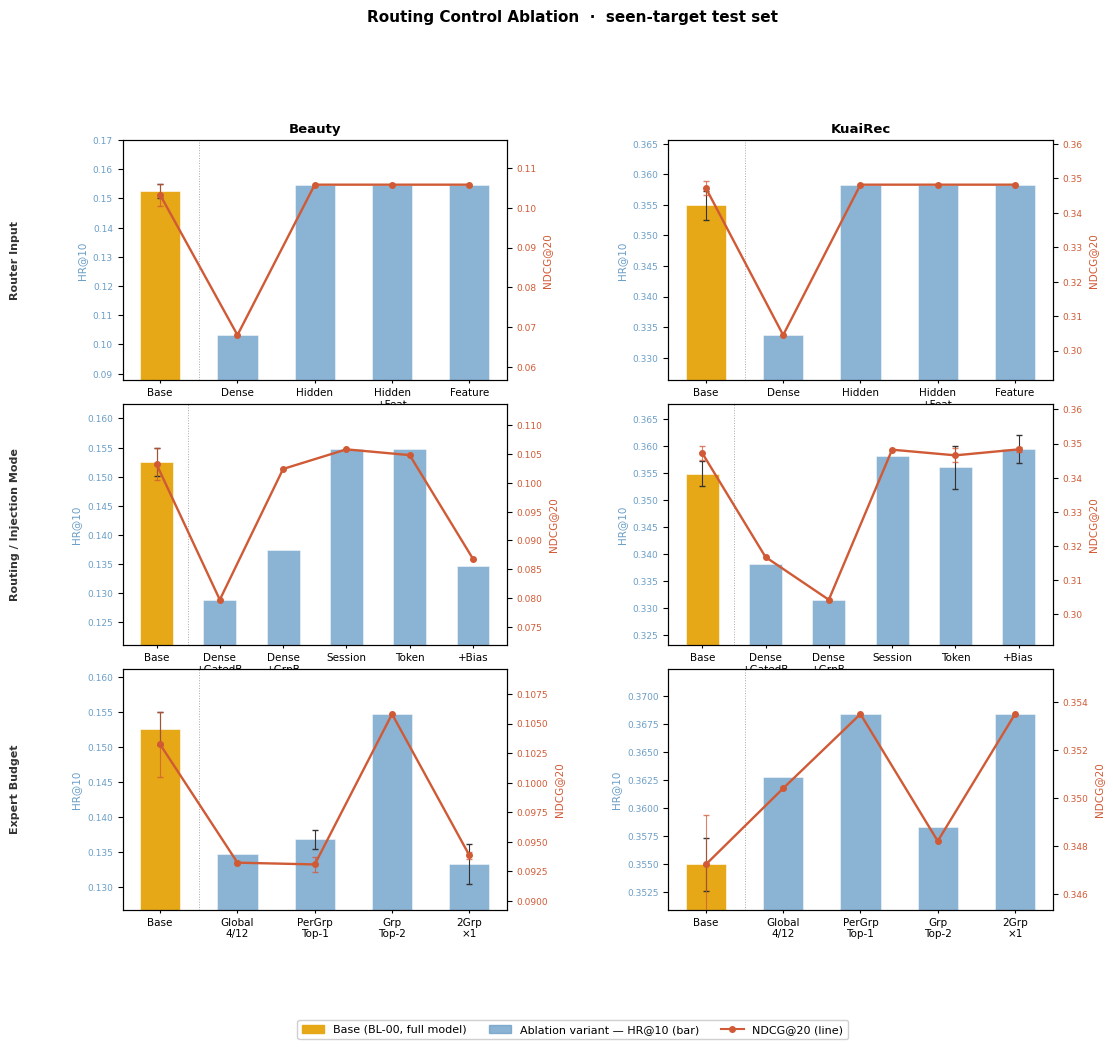

In [20]:

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# ── Group definitions ──────────────────────────────────────────────────────
GROUPS = [
    {
        "label":   "Router Input",
        "rc_ids":  ["BL-00", "RC-01", "RC-02", "RC-03", "RC-04"],
        "xlabels": ["Base", "Dense", "Hidden", "Hidden\n+Feat", "Feature"],
    },
    {
        "label":   "Routing / Injection Mode",
        "rc_ids":  ["BL-00", "RC-05", "RC-06", "RC-11", "RC-12", "RC-13"],
        "xlabels": ["Base", "Dense\n+GatedB", "Dense\n+GrpB", "Session", "Token", "+Bias"],
    },
    {
        "label":   "Expert Budget",
        "rc_ids":  ["BL-00", "RC-07", "RC-08", "RC-09", "RC-10"],
        "xlabels": ["Base", "Global\n4/12", "PerGrp\nTop-1", "Grp\nTop-2", "2Grp\n×1"],
    },
]

# ── Colors ─────────────────────────────────────────────────────────────────
CLR_BL    = "#E6A817"   # amber  — BL-00 (baseline / final model)
CLR_BAR   = "#6B9EC7"   # steel blue — ablation bars HR@10
CLR_LINE  = "#D05A35"   # burnt orange — NDCG@20 line
BAR_W     = 0.52

def tight_ylim(vals, pad=0.30):
    v = [x for x in np.asarray(vals).flatten() if not np.isnan(x)]
    if not v:
        return 0, 1
    lo, hi = min(v), max(v)
    span = hi - lo if hi > lo else hi * 0.05 if hi > 0 else 0.05
    return max(0.0, lo - pad * span), hi + pad * span

# ── Figure: 3 rows × 2 cols ────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 10))
outer = gridspec.GridSpec(3, 1, hspace=0.10, figure=fig)

# We need twin-axis, so build manual grid: 3 rows, 2 cols subplots
axes   = np.empty((3, 2), dtype=object)
axes2  = np.empty((3, 2), dtype=object)

gs_rows = []
for r in range(3):
    gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[r], wspace=0.42)
    gs_rows.append(gs)
    for c in range(2):
        ax  = fig.add_subplot(gs[0, c])
        ax2 = ax.twinx()
        axes[r, c]  = ax
        axes2[r, c] = ax2

for row_i, grp in enumerate(GROUPS):
    for col_i, ds_key in enumerate(DATASET_KEYS):
        ax      = axes[row_i, col_i]
        ax2     = axes2[row_i, col_i]
        agg_idx = results[ds_key].set_index("setting_id")
        b       = bl00[ds_key]

        # Build value arrays (BL-00 first, then RC variants)
        rc_rest = [r for r in grp["rc_ids"] if r != "BL-00" and r in agg_idx.index]
        id_seq  = ["BL-00"] + rc_rest
        xl_seq  = ["Base"] + [grp["xlabels"][grp["rc_ids"].index(r)] for r in rc_rest]

        hr10     = np.array([b["mean_hr10"]   if i == "BL-00" else agg_idx.loc[i, "mean_hr10"]   for i in id_seq])
        hr10_e   = np.array([b["std_hr10"]    if i == "BL-00" else agg_idx.loc[i, "std_hr10"]    for i in id_seq])
        ndcg20   = np.array([b["mean_ndcg20"] if i == "BL-00" else agg_idx.loc[i, "mean_ndcg20"] for i in id_seq])
        ndcg20_e = np.array([b["std_ndcg20"]  if i == "BL-00" else agg_idx.loc[i, "std_ndcg20"]  for i in id_seq])

        x = np.arange(len(id_seq))
        bar_colors = [CLR_BL if i == "BL-00" else CLR_BAR for i in id_seq]
        bar_alphas = [1.0    if i == "BL-00" else 0.78     for i in id_seq]

        # ── HR@10 bars (left y) ───────────────────────────────────────────
        for xi, (h, e, c, a) in enumerate(zip(hr10, hr10_e, bar_colors, bar_alphas)):
            ax.bar(xi, h, color=c, alpha=a, width=BAR_W, edgecolor="white", linewidth=0.4)
            if not np.isnan(e) and e > 0:
                ax.errorbar(xi, h, yerr=e, fmt="none", color="#333", capsize=2.5, lw=0.8)

        ax.set_ylim(tight_ylim(np.append(hr10, ndcg20 * 1.0)))   # share room
        ax.set_ylim(tight_ylim(hr10))
        ax.set_ylabel("HR@10", fontsize=7.5, color=CLR_BAR)
        ax.tick_params(axis="y", labelcolor=CLR_BAR, labelsize=6.5)

        # ── NDCG@20 line (right y) ────────────────────────────────────────
        ax2.plot(x, ndcg20, color=CLR_LINE, lw=1.7, marker="o", markersize=4, zorder=5)
        for xi, (n, e) in enumerate(zip(ndcg20, ndcg20_e)):
            if not np.isnan(e) and e > 0:
                ax2.errorbar(xi, n, yerr=e, fmt="none", color=CLR_LINE,
                             capsize=2.5, lw=0.8, alpha=0.75, zorder=5)

        ax2.set_ylim(tight_ylim(ndcg20))
        ax2.set_ylabel("NDCG@20", fontsize=7.5, color=CLR_LINE)
        ax2.tick_params(axis="y", labelcolor=CLR_LINE, labelsize=6.5)

        # ── X-axis ────────────────────────────────────────────────────────
        ax.set_xticks(x)
        ax.set_xticklabels(xl_seq, fontsize=7.5)
        ax.tick_params(axis="x", length=2)

        # ── Subplot title: dataset name only ──────────────────────────────
        if row_i == 0:
            ax.set_title(DATASET_LABELS[ds_key], fontsize=9.5, fontweight="bold", pad=5)

        # Draw a thin vertical separator after BL-00
        ax.axvline(0.5, color="#aaa", lw=0.7, ls=":", zorder=0)

    # ── Row label on the left ─────────────────────────────────────────────
    axes[row_i, 0].annotate(
        grp["label"], xy=(-0.28, 0.5), xycoords="axes fraction",
        ha="center", va="center", rotation=90,
        fontsize=8, fontweight="bold", color="#333",
    )

# ── Legend (bottom-center, outside figure) ───────────────────────────────
leg_handles = [
    Patch(color=CLR_BL,  label="Base (BL-00, full model)"),
    Patch(color=CLR_BAR, alpha=0.78, label="Ablation variant — HR@10 (bar)"),
    Line2D([0],[0], color=CLR_LINE, marker="o", ms=4, label="NDCG@20 (line)"),
]
fig.legend(
    handles=leg_handles, fontsize=8,
    loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.025),
    framealpha=0.92,
)

fig.suptitle(
    "Routing Control Ablation  ·  seen-target test set",
    fontsize=11, fontweight="bold", y=1.01,
)
plt.show()


In [21]:

# ── Summary table ─────────────────────────────────────────────────────────
print("=" * 90)
for ds in DATASET_KEYS:
    agg   = results[ds].copy()
    base  = bl00[ds]
    label = DATASET_LABELS[ds]
    agg["lift_hr10_%"]   = (agg["mean_hr10"]   - base["mean_hr10"])   / base["mean_hr10"]   * 100
    agg["lift_ndcg20_%"] = (agg["mean_ndcg20"] - base["mean_ndcg20"]) / base["mean_ndcg20"] * 100
    print(f"  {label}  —  BL-00 HR@10={base['mean_hr10']:.4f}±{base['std_hr10']:.4f}  "
          f"NDCG@20={base['mean_ndcg20']:.4f}±{base['std_ndcg20']:.4f}")
    print("-" * 90)
    cols = ["setting_id", "setting_key", "n_seeds",
            "mean_hr10", "std_hr10", "lift_hr10_%",
            "mean_ndcg20", "std_ndcg20", "lift_ndcg20_%"]
    print(agg[cols].to_string(index=False, float_format="{:.4f}".format))
    best = agg.loc[agg["mean_hr10"].idxmax()]
    print(f"  ★ Best HR@10:   {best['setting_id']} ({best['setting_key']}) "
          f"= {best['mean_hr10']:.4f} ({best['lift_hr10_%']:+.2f}%)")
    best2 = agg.loc[agg["mean_ndcg20"].idxmax()]
    print(f"  ★ Best NDCG@20: {best2['setting_id']} ({best2['setting_key']}) "
          f"= {best2['mean_ndcg20']:.4f} ({best2['lift_ndcg20_%']:+.2f}%)")
    print()


  Beauty  —  BL-00 HR@10=0.1526±0.0024  NDCG@20=0.1032±0.0027
------------------------------------------------------------------------------------------
setting_id                     setting_key  n_seeds  mean_hr10  std_hr10  lift_hr10_%  mean_ndcg20  std_ndcg20  lift_ndcg20_%
     RC-01                      SHARED_FFN        1     0.1032       NaN     -32.3611       0.0680         NaN       -34.1245
     RC-02            ROUTER_SOURCE_HIDDEN        1     0.1547       NaN       1.3928       0.1058         NaN         2.4946
     RC-03              ROUTER_SOURCE_BOTH        4     0.1547    0.0000       1.3928       0.1058      0.0000         2.4946
     RC-04           ROUTER_SOURCE_FEATURE        1     0.1547       NaN       1.3928       0.1058         NaN         2.4946
     RC-05   NO_ROUTER_WITH_BIAS_INJECTION        1     0.1289       NaN     -15.5170       0.0797         NaN       -22.7900
     RC-06 NO_ROUTER_WITH_GROUP_GATED_BIAS        1     0.1375       NaN      -9.8804      